<h2 style= 'text-align:center; color:#27AE60; font-weight:bold;font-size:40px;  text-shadow:0 0 3px rgba(15,52,96,0.6);'>EDA on Fake News Detection Dataset</h2>

#### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Step 1 — Install & Import Libraries</span>

In [1]:
import os
import re
from pathlib import Path
import pandas as pd
from matplotlib import pyplot as plt
import string
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords', quiet=True)
from wordcloud import WordCloud

# Display Markdown
from IPython.display import display, Markdown

import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)

display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Libraries Loaded!</span>"))

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Libraries Loaded!</span>

#### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Step 2 — Load & Inspect Dataset</span>

In [2]:
BASE_DIR = Path('1_eda.ipynb').resolve().parent.parent
print(f"Base Directory: {BASE_DIR}")
file_path = rf"{BASE_DIR}\data\fake_and_real_news.csv"
print(f"File Path: {file_path}")

Base Directory: D:\Education\AiQuest\DS,ML,DL\Projects\Fake News Classifier
File Path: D:\Education\AiQuest\DS,ML,DL\Projects\Fake News Classifier\data\fake_and_real_news.csv


In [3]:

df  = pd.read_csv(file_path)

display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Dataset successfully Loaded!</span>"))

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Dataset successfully Loaded!</span>

In [4]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Shape of the Dataset.</span>"))

display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Number of Rows: {df.shape[0]}</span>"))
display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Number of Columns: {df.shape[1]}</span>"))
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>First Few Rows of the Dataset.</span>"))
display(df.head())

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Shape of the Dataset.</span>

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Number of Rows: 9900</span>

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Number of Columns: 2</span>

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>First Few Rows of the Dataset.</span>

,Text,label
0,Top Trump Surrogate BRUTALLY Stabs Him In The...,Fake
1,U.S. conservative leader optimistic of common ...,Real
2,"Trump proposes U.S. tax overhaul, stirs concer...",Real
3,Court Forces Ohio To Allow Millions Of Illega...,Fake
4,Democrats say Trump agrees to work on immigrat...,Real


In [5]:
display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Missing Values in Each Column:</span>"))
display(df.isnull().sum())

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Missing Values in Each Column:</span>

Text     0
label    0
dtype: int64

In [6]:
display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Data Types of Each Column:</span>"))
display(df.dtypes)

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Data Types of Each Column:</span>

Text     str
label    str
dtype: object

In [7]:
display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Checking for Duplicates:</span>"))
display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Number of Duplicate Rows: {df.duplicated().sum()}</span>"))
display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Dropping Duplicate Rows...</span>"))
df.drop_duplicates(inplace=True)
display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Shape of the Dataset after Dropping Duplicates: {df.shape[0]} rows, {df.shape[1]} columns</span>"))

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Checking for Duplicates:</span>

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Number of Duplicate Rows: 35</span>

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Dropping Duplicate Rows...</span>

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Shape of the Dataset after Dropping Duplicates: 9865 rows, 2 columns</span>

#### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Step 3 — Label distribution</span>

In [8]:
#df['label'] = df['label'].map({'REAL': 0, 'FAKE': 1})
#display(Markdown("### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Label Encoding Completed!</span>"))

In [9]:
label_counts = df['label'].value_counts()
total = label_counts.sum()

print("Label Distribution:")
print(label_counts)
print("\nTotal Samples:", total)

Label Distribution:
label
Fake    5000
Real    4865
Name: count, dtype: int64

Total Samples: 9865


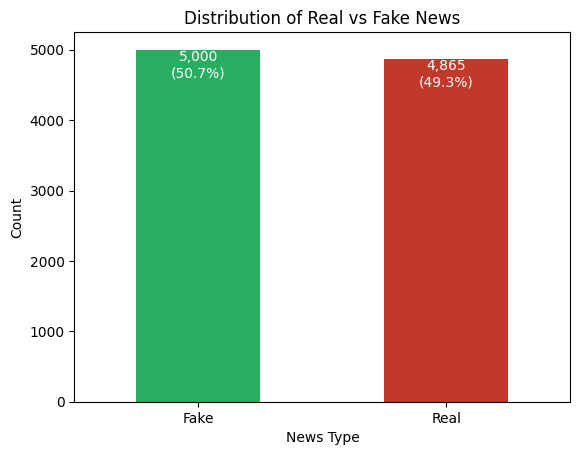

In [10]:
ax = label_counts.plot(kind='bar', color=['#27AE60', '#C0392B'])
plt.title('Distribution of Real vs Fake News')
plt.xlabel('News Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
for i, count in enumerate(label_counts):
    percentage = 100 * count / total
    ax.text(
        i,
        count,
        f'{count:,}\n({percentage:.1f}%)',
        ha='center',
        va='top',
        color='white',
    )
plt.show()

#### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Step 4 — Text length analysis</span>

In [11]:
# Calculate text length (number of words) and add it as a new column to the DataFrame
df['text_length'] = df['Text'].str.split().str.len()
print(df.groupby('label')['text_length'].describe())

        count        mean         std   min    25%    50%    75%     max
label                                                                   
Fake   5000.0  449.408800  149.539806  46.0  354.0  419.0  517.0  3927.0
Real   4865.0  394.926413  282.306546  35.0  133.0  381.0  554.0  5181.0


<Figure size 800x600 with 0 Axes>

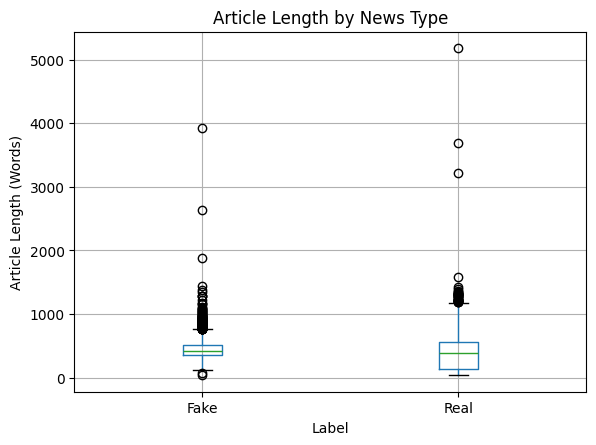

In [12]:
plt.figure(figsize=(8, 6))

df.boxplot(column='text_length', by='label')

plt.title('Article Length by News Type')
plt.suptitle('')
plt.xlabel('Label')
plt.ylabel('Article Length (Words)')
plt.show()

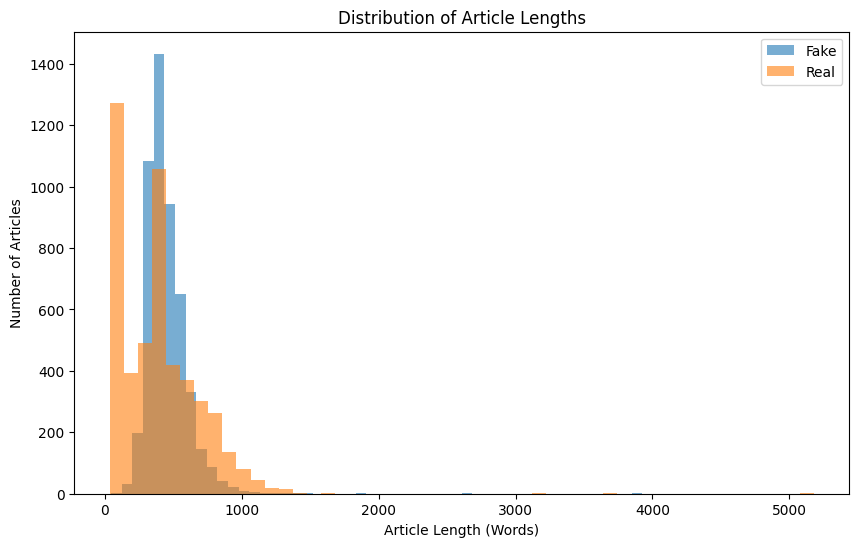

In [13]:
plt.figure(figsize=(10, 6))

plt.hist(
    df[df['label'] == 'Fake']['text_length'],
    bins=50,
    alpha=0.6,
    label='Fake'
)

plt.hist(
    df[df['label'] == 'Real']['text_length'],
    bins=50,
    alpha=0.6,
    label='Real'
)

plt.xlabel('Article Length (Words)')
plt.ylabel('Number of Articles')
plt.title('Distribution of Article Lengths')
plt.legend()
plt.show()

#### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Key Findings</span>

1. Fake articles are slightly longer on average
2. Both the mean and median are higher for Fake articles
3. Real articles have much greater variability<br>
Compare the standard deviations:
- Fake: 149.5
- Real: 282.3
4. Real articles contain more extreme lengths

#### <span style='color:#27AE60; font-weight:bold;font-size:24px; text-shadow:0 0 3px rgba(15,52,96,0.6);'>Step 5 — Most common words</span>

In [14]:
stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    return text

def get_top_n_words(text_series, n=20):
    words = []

    for sentence in text_series:
        sentence = clean_text(sentence)
        tokens = sentence.split()

        words.extend([
            word for word in tokens
            if word.isalpha() and word not in stop_words
        ])

    word_freq = pd.Series(words).value_counts()

    return word_freq.head(n)

fake_text = df[df['label'] == 'Fake']['Text']
real_text = df[df['label'] == 'Real']['Text']
top_fake_words = get_top_n_words(fake_text)
top_real_words = get_top_n_words(real_text)
print("Top 20 Words in Fake News:")
print(top_fake_words)
print("\nTop 20 Words in Real News:")
print(top_real_words)


Top 20 Words in Fake News:
trump        36496
donald        7617
people        6993
president     6535
said          6414
would         5686
one           5597
via           4813
like          4802
image         4713
even          4351
white         4254
obama         3529
house         3440
us            3360
also          3285
time          3218
images        3115
get           3041
going         3002
Name: count, dtype: int64

Top 20 Words in Real News:
said          22442
trump         16714
us            14784
would          8957
president      8456
house          8439
reuters        6162
republican     5623
tax            5485
senate         5154
trumps         5152
washington     4837
states         4591
white          4570
new            4002
bill           4001
donald         3893
state          3822
also           3806
could          3566
Name: count, dtype: int64


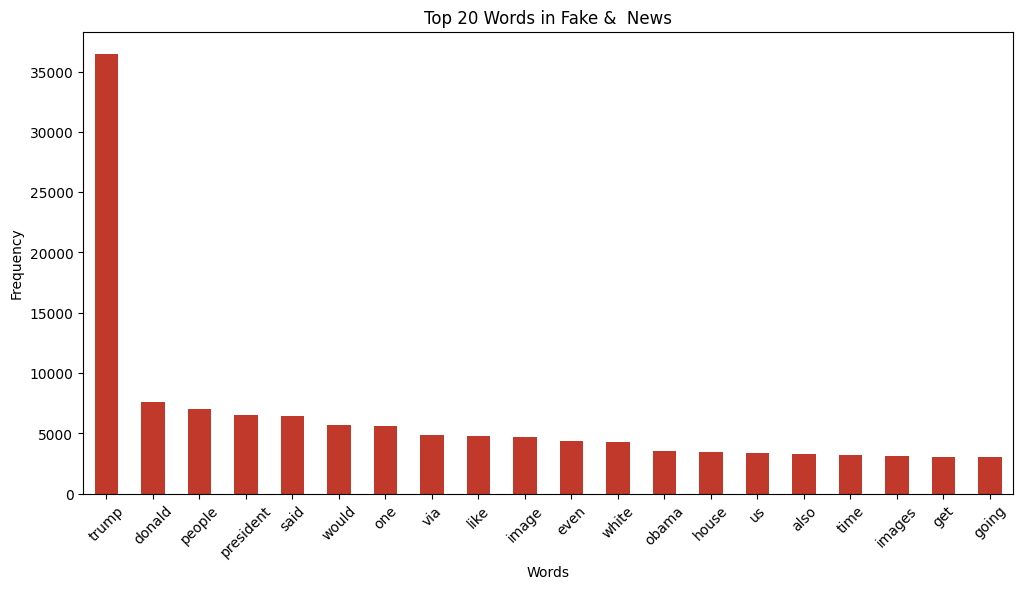

In [15]:
plt.figure(figsize=(12, 6))
top_fake_words.plot(kind='bar', color='#C0392B')
plt.title('Top 20 Words in Fake &  News')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

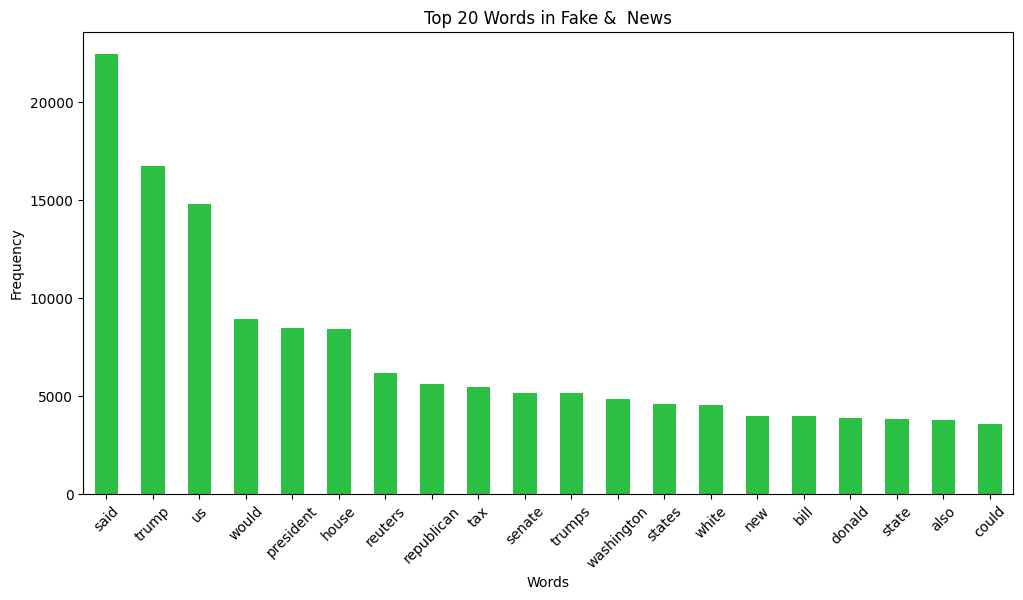

In [16]:
plt.figure(figsize=(12, 6))
top_real_words.plot(kind='bar', color="#2BC044")
plt.title('Top 20 Words in Fake &  News')
plt.xlabel('Words')
plt.ylabel('Frequency')
plt.xticks(rotation=45)
plt.show()

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Word Cloud of Real News</span>

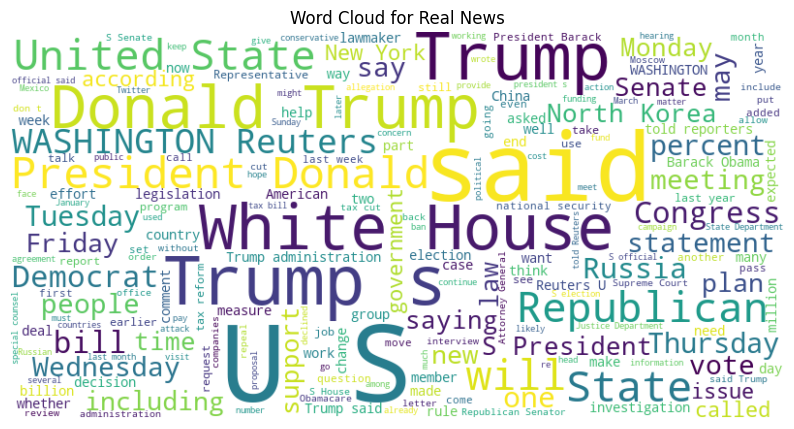

### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Word Cloud of Fake News</span>

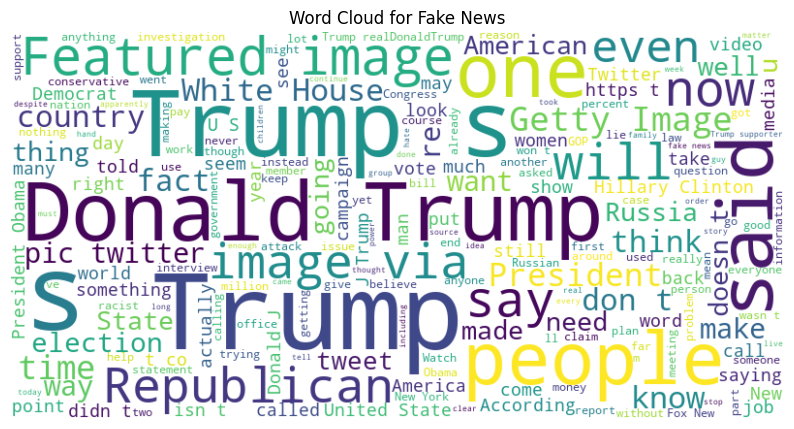

In [17]:
def plot_wordcloud(text,title):
    wordcloud = WordCloud(width=800, height=400, random_state=21, max_font_size=110, background_color='white').generate(text)
    plt.figure(figsize=(10, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis('off')
    plt.title(title)
    plt.show()

real_news = ' '.join(df[df['label'] == 'Real']['Text'])
fake_news = ' '.join(df[df['label'] == 'Fake']['Text'])

display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Word Cloud of Real News</span>"))
plot_wordcloud(real_news, 'Word Cloud for Real News')
display(Markdown(f"### <span style='color:#27AE60; font-weight:bold;font-size:16px; text-shadow:0 0 0px rgba(15,52,96,0.6);'>Word Cloud of Fake News</span>"))
plot_wordcloud(fake_news, 'Word Cloud for Fake News')